# Models

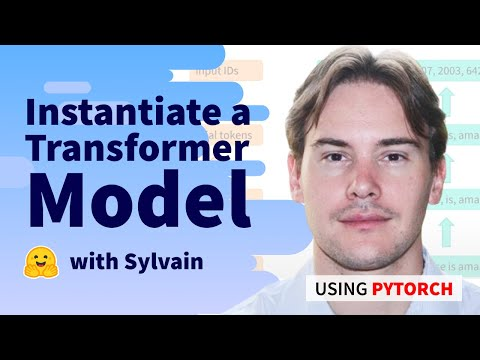

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo("AhChOFRegn4", width=800, height=450)

In this section, we’ll take a closer look at creating and using models. We’ll use the `AutoModel` class, which is handy when you want to instantiate any model from a checkpoint.

## Creating a Transformer

Let’s begin by examining what happens when we instantiate an `AutoModel`:

In [2]:
from transformers import AutoModel

model = AutoModel.from_pretrained("bert-base-cased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Similar to the tokenizer, the `from_pretrained()` method will download and cache the model data from the Hugging Face Hub. As mentioned previously, the checkpoint name corresponds to a specific model architecture and weights, in this case a BERT model with a basic architecture (12 layers, 768 hidden size, 12 attention heads) and cased inputs (meaning that the uppercase/lowercase distinction is important). There are many checkpoints available on the Hub — you can explore them [here](https://huggingface.co/models).

The `AutoModel` class and its associates are actually simple wrappers designed to fetch the appropriate model architecture for a given checkpoint. It’s an “auto” class meaning it will guess the appropriate model architecture for you and instantiate the correct model class. However, if you know the type of model you want to use, you can use the class that defines its architecture directly:

In [3]:
from transformers import BertModel

model = BertModel.from_pretrained("bert-base-cased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Loading and saving

Saving a model is as simple as saving a tokenizer. In fact, the models actually have the same `save_pretrained()` method, which saves the model’s weights and architecture configuration:

In [4]:
model.save_pretrained("./directory_on_my_computer")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
ls directory_on_my_computer

config.json        model.safetensors


---

If you look inside the *config.json* file, you’ll see all the necessary attributes needed to build the model architecture. This file also contains some metadata, such as where the checkpoint originated and what `🤗 Transformers` version you were using when you last saved the checkpoint.

The *pytorch_model.safetensors* file is known as the state dictionary; it contains all your model’s weights. The two files work together: the configuration file is needed to know about the model architecture, while the model weights are the parameters of the model.

To reuse a saved model, use the `from_pretrained()` method again:

In [6]:
from transformers import AutoModel

model = AutoModel.from_pretrained("directory_on_my_computer")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

A wonderful feature of the `🤗 Transformers` library is the ability to easily share models and tokenizers with the community. To do this, make sure you have an account on [Hugging Face](https://huggingface.co/). If you’re using a notebook, you can easily log in with this:

In [7]:
from huggingface_hub import notebook_login

notebook_login()

Otherwise, at your terminal run:

In [8]:
!hf auth login

User is already logged in. Use `hf auth login --force` to force re-login.


In [9]:
model.push_to_hub("my-awesome-model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/tankgauravgt/my-awesome-model/commit/01ae4060f14e0493d885df05c1162de6af295cb8', commit_message='Upload model', commit_description='', oid='01ae4060f14e0493d885df05c1162de6af295cb8', pr_url=None, repo_url=RepoUrl('https://huggingface.co/tankgauravgt/my-awesome-model', endpoint='https://huggingface.co', repo_type='model', repo_id='tankgauravgt/my-awesome-model'), pr_revision=None, pr_num=None)

---

This will upload the model files to the Hub, in a repository under your namespace named `my-awesome-model`. Then, anyone can load your model with the `from_pretrained()` method!

In [10]:
from transformers import AutoModel

model = AutoModel.from_pretrained("tankgauravgt/my-awesome-model")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

You can do a lot more with the Hub API:

- Push a model from a local repository
- Update specific files without re-uploading everything
- Add model cards to document the model’s abilities, limitations, known biases, etc.

See the [documentation](https://huggingface.co/docs/huggingface_hub/how-to-upstream) for a complete tutorial on this, or check out the advanced [Chapter 4](https://huggingface.co/course/chapter4).

## Encoding text

Transformer models handle text by turning the inputs into numbers. Here we will look at exactly what happens when your text is processed by the tokenizer. We’ve already seen in [Chapter 1](https://huggingface.co/course/chapter1) that tokenizers split the text into tokens and then convert these tokens into numbers. We can see this conversion through a simple tokenizer:

In [11]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

encoded_input = tokenizer("Hello, I'm a single sentence!")

for k, v in encoded_input.items():
    print(f"`{k}`:")
    print(v)
    print()

`input_ids`:
[101, 8667, 117, 146, 112, 182, 170, 1423, 5650, 106, 102]

`token_type_ids`:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

`attention_mask`:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]



We get a dictionary with the following fields:

- **input_ids:** numerical representations of your tokens
- **token_type_ids:** these tell the model which part of the input is sentence A and which is sentence B (discussed more in the next section)
- **attention_mask:** this indicates which tokens should be attended to and which should not (discussed more in a bit)

We can decode the input IDs to get back the original text:

In [12]:
tokenizer.decode(encoded_input["input_ids"])

"[CLS] Hello, I ' m a single sentence! [SEP]"

---

You’ll notice that the tokenizer has added special tokens — `[CLS]` and `[SEP]` — required by the model. Not all models need special tokens; they’re utilized when a model was pretrained with them, in which case the tokenizer needs to add them as that model expects these tokens.

You can encode multiple sentences at once, either by batching them together (we’ll discuss this soon) or by passing a list:

In [14]:
encoded_input = tokenizer(
    [
        "How are you?", 
        "I'm fine, thank you!"
    ], 
    truncation=True, 
    padding=True
)

for k, v in encoded_input.items():
    print(f"`{k}`:")
    print(v)
    print()

`input_ids`:
[[101, 1731, 1132, 1128, 136, 102, 0, 0, 0, 0], [101, 146, 112, 182, 2503, 117, 6243, 1128, 106, 102]]

`token_type_ids`:
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

`attention_mask`:
[[1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]



Note that when passing multiple sentences, the tokenizer returns a list for each sentence for each dictionary value. We can also ask the tokenizer to return tensors directly from PyTorch:

In [15]:
encoded_input = tokenizer(
    [
        "How are you?", 
        "I'm fine, thank you!"
    ], 
    truncation=True, 
    padding=True, 
    return_tensors="pt"
)

for k, v in encoded_input.items():
    print(f"`{k}`:")
    print(v)
    print()

`input_ids`:
tensor([[ 101, 1731, 1132, 1128,  136,  102,    0,    0,    0,    0],
        [ 101,  146,  112,  182, 2503,  117, 6243, 1128,  106,  102]])

`token_type_ids`:
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

`attention_mask`:
tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])



But there’s a problem: the two lists don’t have the same length! Arrays and tensors need to be rectangular, so we can’t simply convert these lists to a PyTorch tensor (or NumPy array). The tokenizer provides an option for that: padding.

### Padding inputs

If we ask the tokenizer to pad the inputs, it will make all sentences the same length by adding a special padding token to the sentences that are shorter than the longest one:

In [16]:
encoded_input = tokenizer(
    [
        "How are you?", 
        "I'm fine, thank you!"
    ], 
    padding=True, 
    return_tensors="pt"
)

for k, v in encoded_input.items():
    print(f"`{k}`:")
    print(v)
    print()

`input_ids`:
tensor([[ 101, 1731, 1132, 1128,  136,  102,    0,    0,    0,    0],
        [ 101,  146,  112,  182, 2503,  117, 6243, 1128,  106,  102]])

`token_type_ids`:
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

`attention_mask`:
tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])



Now we have rectangular tensors! Note that the padding tokens have been encoded into input IDs with ID 0, and they have an attention mask value of 0 as well. This is because those padding tokens shouldn’t be analyzed by the model: they’re not part of the actual sentence.

### Truncating inputs

The tensors might get too big to be processed by the model. For instance, BERT was only pretrained with sequences up to 512 tokens, so it cannot process longer sequences. If you have sequences longer than the model can handle, you’ll need to truncate them with the truncation parameter:

In [17]:
encoded_input = tokenizer(
    f"This is a {'very ' * 1_000_000} long sentence.",
    truncation=True,
)

print(encoded_input["input_ids"])

[101, 1188, 1110, 170, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304, 1304,

In [18]:
tokenizer.init_kwargs

{'do_lower_case': False,
 'unk_token': '[UNK]',
 'sep_token': '[SEP]',
 'pad_token': '[PAD]',
 'cls_token': '[CLS]',
 'mask_token': '[MASK]',
 'tokenize_chinese_chars': True,
 'strip_accents': None,
 'model_max_length': 512,
 'vocab_file': './hf_cache/hub/models--bert-base-cased/snapshots/cd5ef92a9fb2f889e972770a36d4ed042daf221e/vocab.txt',
 'name_or_path': 'bert-base-cased',
 'is_local': False,
 'local_files_only': False,
 'added_tokens_decoder': {0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
  100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
  101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
  102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
  103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True)},
 'backend': 't

---

By combining the padding and truncation arguments, you can make sure your tensors have the exact size you need:

In [19]:
encoded_input = tokenizer(
    [
        "How are you?", 
        "I'm fine, thank you!"
    ],
    padding=True,
    truncation=True,
    max_length=5,
    return_tensors="pt",
)

for k, v in encoded_input.items():
    print(f"`{k}`:")
    print(v)
    print()

`input_ids`:
tensor([[ 101, 1731, 1132, 1128,  102],
        [ 101,  146,  112,  182,  102]])

`token_type_ids`:
tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]])

`attention_mask`:
tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]])



### Adding special tokens

Special tokens (or at least the concept of them) is particularly important to BERT and derived models. These tokens are added to better represent the sentence boundaries, such as the beginning of a sentence (`[CLS]`) or separator between sentences (`[SEP]`). Let’s look at a simple example:

In [20]:
encoded_input = tokenizer("How are you?")

for k, v in encoded_input.items():
    print(f"`{k}`:")
    print(v)
    print()

`input_ids`:
[101, 1731, 1132, 1128, 136, 102]

`token_type_ids`:
[0, 0, 0, 0, 0, 0]

`attention_mask`:
[1, 1, 1, 1, 1, 1]



In [21]:
tokenizer.decode(encoded_input["input_ids"])

'[CLS] How are you? [SEP]'

These special tokens are automatically added by the tokenizer. Not all models need special tokens; they are primarily used when a model was pretrained with them, in which case the tokenizer will add them since the model expects them.

### Why is all of this necessary?

Here’s a concrete example. Consider these encoded sequences:

In [22]:
sequences = [
    "I've been waiting for a HuggingFace course my whole life.",
    "I hate this so much!",
]

Once tokenized, we have:

In [23]:
from pprint import pprint

encoded_sequences = tokenizer(sequences, padding=True, truncation=True)

for k, v in encoded_sequences.items():
    print(f"`{k}`:")
    pprint(v)
    print()

`input_ids`:
[[101,
  146,
  112,
  1396,
  1151,
  2613,
  1111,
  170,
  20164,
  10932,
  2271,
  7954,
  1736,
  1139,
  2006,
  1297,
  119,
  102],
 [101, 146, 4819, 1142, 1177, 1277, 106, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

`token_type_ids`:
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

`attention_mask`:
[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]



---

This is a list of encoded sequences: a list of lists. Tensors only accept rectangular shapes (think matrices). This “array” is already of rectangular shape, so converting it to a tensor is easy:

In [24]:
import torch

model_inputs = torch.tensor(encoded_sequences['input_ids'])
model_inputs.shape

torch.Size([2, 18])

### Using the tensors as inputs to the model

Making use of the tensors with the model is extremely simple — we just call the model with the inputs:

In [25]:
outputs = model(model_inputs)

In [26]:
outputs.last_hidden_state.shape

torch.Size([2, 18, 768])

---

While the model accepts a lot of different arguments, only the input IDs are necessary. We’ll explain what the other arguments do and when they are required later, but first we need to take a closer look at the tokenizers that build the inputs that a Transformer model can understand.